<a href="https://colab.research.google.com/github/LeonardoFisAct/DSML_Notes/blob/main/MII_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importación de librerias a utilzar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt #interactive graphs
from sklearn.manifold import TSNE #Non linear dimensianlity reduction

#PCA
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, scale
from sklearn.preprocessing import RobustScaler, robust_scale

#matriz de confusión
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

#Rostros
from sklearn.datasets import fetch_lfw_people

from sklearn.model_selection import train_test_split

#K-means
from sklearn.cluster import KMeans

#Aglomerativos
from sklearn.cluster import AgglomerativeClustering

# Dendograma
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram

#DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.metrics import DistanceMetric
from sklearn.neighbors import kneighbors_graph, NearestNeighbors

# Gaussian Mixtures GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Propagación por afinidad
from sklearn.cluster import AffinityPropagation

#BIRCH
from sklearn.cluster import Birch

# Base de Datos
Es un dataset con 96 entradas y las siguientes variables

`Pais`: Pais

`Tasa`:Tasa anual de crecimiento de la población.

`Mortalidad`: Tasa de mortalidad infantil por cada 1000 nacidos vivos.

`Mujeres`: Porcentaje de mujeres en la población económicamente activa.

`PNB`: Producto Nacional Bruto (millones de dólares).

`Luz`: Producción de electricidad (millones de KW/h).

`Telefonía`: Líneas telefónicas por cada 1000 habitantes.

`Agua` : Consumo de agua per cápita.

`Bosques`: Proporción de la superficie cubierta por bosques.

`Deforestación`: Tasa anual de deforestación.

`Energía`: Consumo de energía per cápita.

`CO2`: Emisión de CO2 per cápita

In [ ]:
df = pd.read_csv("Pais.csv")
df.head()

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
0,Albania,1.0,30,41,2199,3903,12,94,53,0.0,341,1.2
1,Angola,3.0,124,46,4422,922,6,57,19,0.7,89,0.5
2,Arabia Saudi,4.3,21,13,133540,91019,96,497,1,0.0,4566,13.1
3,Argelia,2.5,34,24,44609,19883,42,180,2,0.8,906,3.0
4,Argentina,1.3,22,31,278431,65962,160,1043,22,0.1,1504,3.5


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pais           96 non-null     object 
 1   Tasa           96 non-null     float64
 2   Mortalidad     96 non-null     int64  
 3   Mujeres        96 non-null     int64  
 4   PNB            96 non-null     int64  
 5   Luz            96 non-null     int64  
 6   Telefonia      96 non-null     int64  
 7   Agua           96 non-null     int64  
 8   Bosques        96 non-null     int64  
 9   Deforestacion  96 non-null     float64
 10  Energia        96 non-null     int64  
 11  CO2            96 non-null     float64
dtypes: float64(3), int64(8), object(1)
memory usage: 9.1+ KB


In [ ]:
#Table with descriptive stats
stats = df.iloc[:,1:].describe().T
stats['skewness'] = df.iloc[:,1:].skew()
stats['kurtosis'] = df.iloc[:,1:].kurtosis()
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Tasa,96.0,1.890729,1.209810,-0.3,0.875,2.0,2.725,5.8,0.350075,0.126916
Mortalidad,96.0,40.416667,33.930166,4.0,11.000,33.5,58.750,148.0,0.944674,0.162233
Mujeres,96.0,37.281250,8.774008,13.0,31.000,39.0,44.000,51.0,-0.740968,0.078011
PNB,96.0,122485.437500,236571.275707,1353.0,8014.250,28770.0,109229.250,1451051.0,3.408035,13.469275
Luz,96.0,69292.229167,135073.798195,6.0,4675.750,21422.0,65783.500,928083.0,3.914354,18.945823
Telefonia,96.0,165.125000,195.990991,2.0,15.500,74.0,231.500,681.0,1.173441,-0.040112
Agua,96.0,653.208333,1544.852518,7.0,184.500,395.0,667.000,14602.0,8.086900,71.911841
Bosques,96.0,27.333333,20.025072,0.0,10.000,25.5,42.250,77.0,0.488996,-0.567788
Deforestacion,96.0,1.208333,3.749938,-1.9,0.000,0.6,1.300,36.1,8.665447,80.977434
Energia,96.0,1854.427083,2239.284513,20.0,287.750,914.5,2553.500,10531.0,1.730794,2.892471


Se observan variables con un alto sesgo positivo y una curtosis muy alta indicando la posible presencia de outliers en ellas asi como la mayor concentración de los datos en valores pequeños (`Agua` y `Deforestación`)

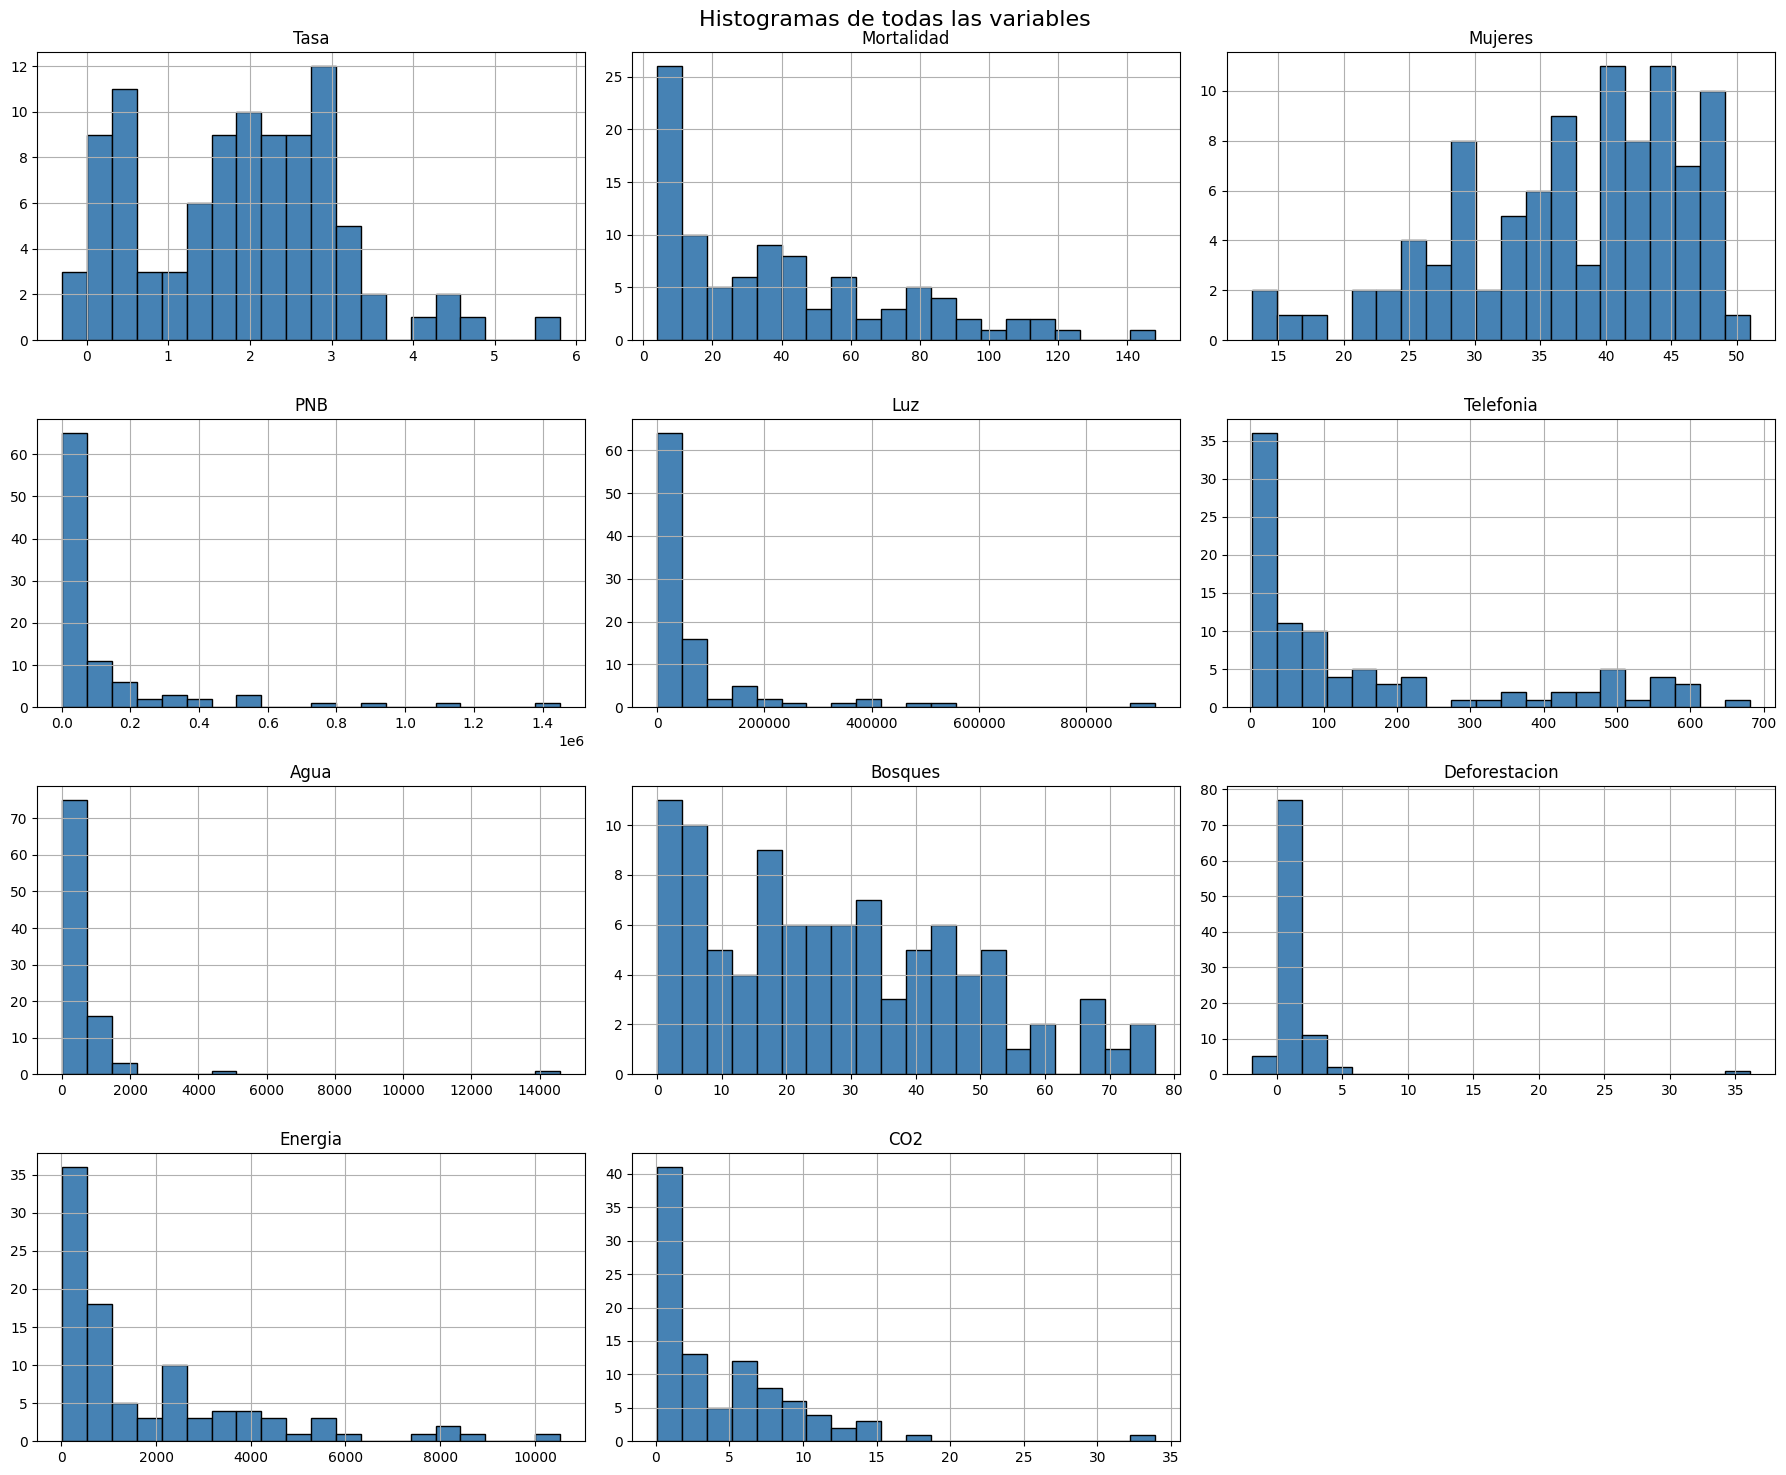

In [ ]:
# Histograma
df.drop(columns='Pais').hist(bins=20, figsize=(18, 15), color='steelblue', edgecolor='black')
plt.suptitle("Histogramas de todas las variables", fontsize=16)
plt.tight_layout()
plt.show()

Se confirma de manera visual con un histograma el sesgo en variables como `Agua`, `Deforestación`, `Luz`, `PNB`.

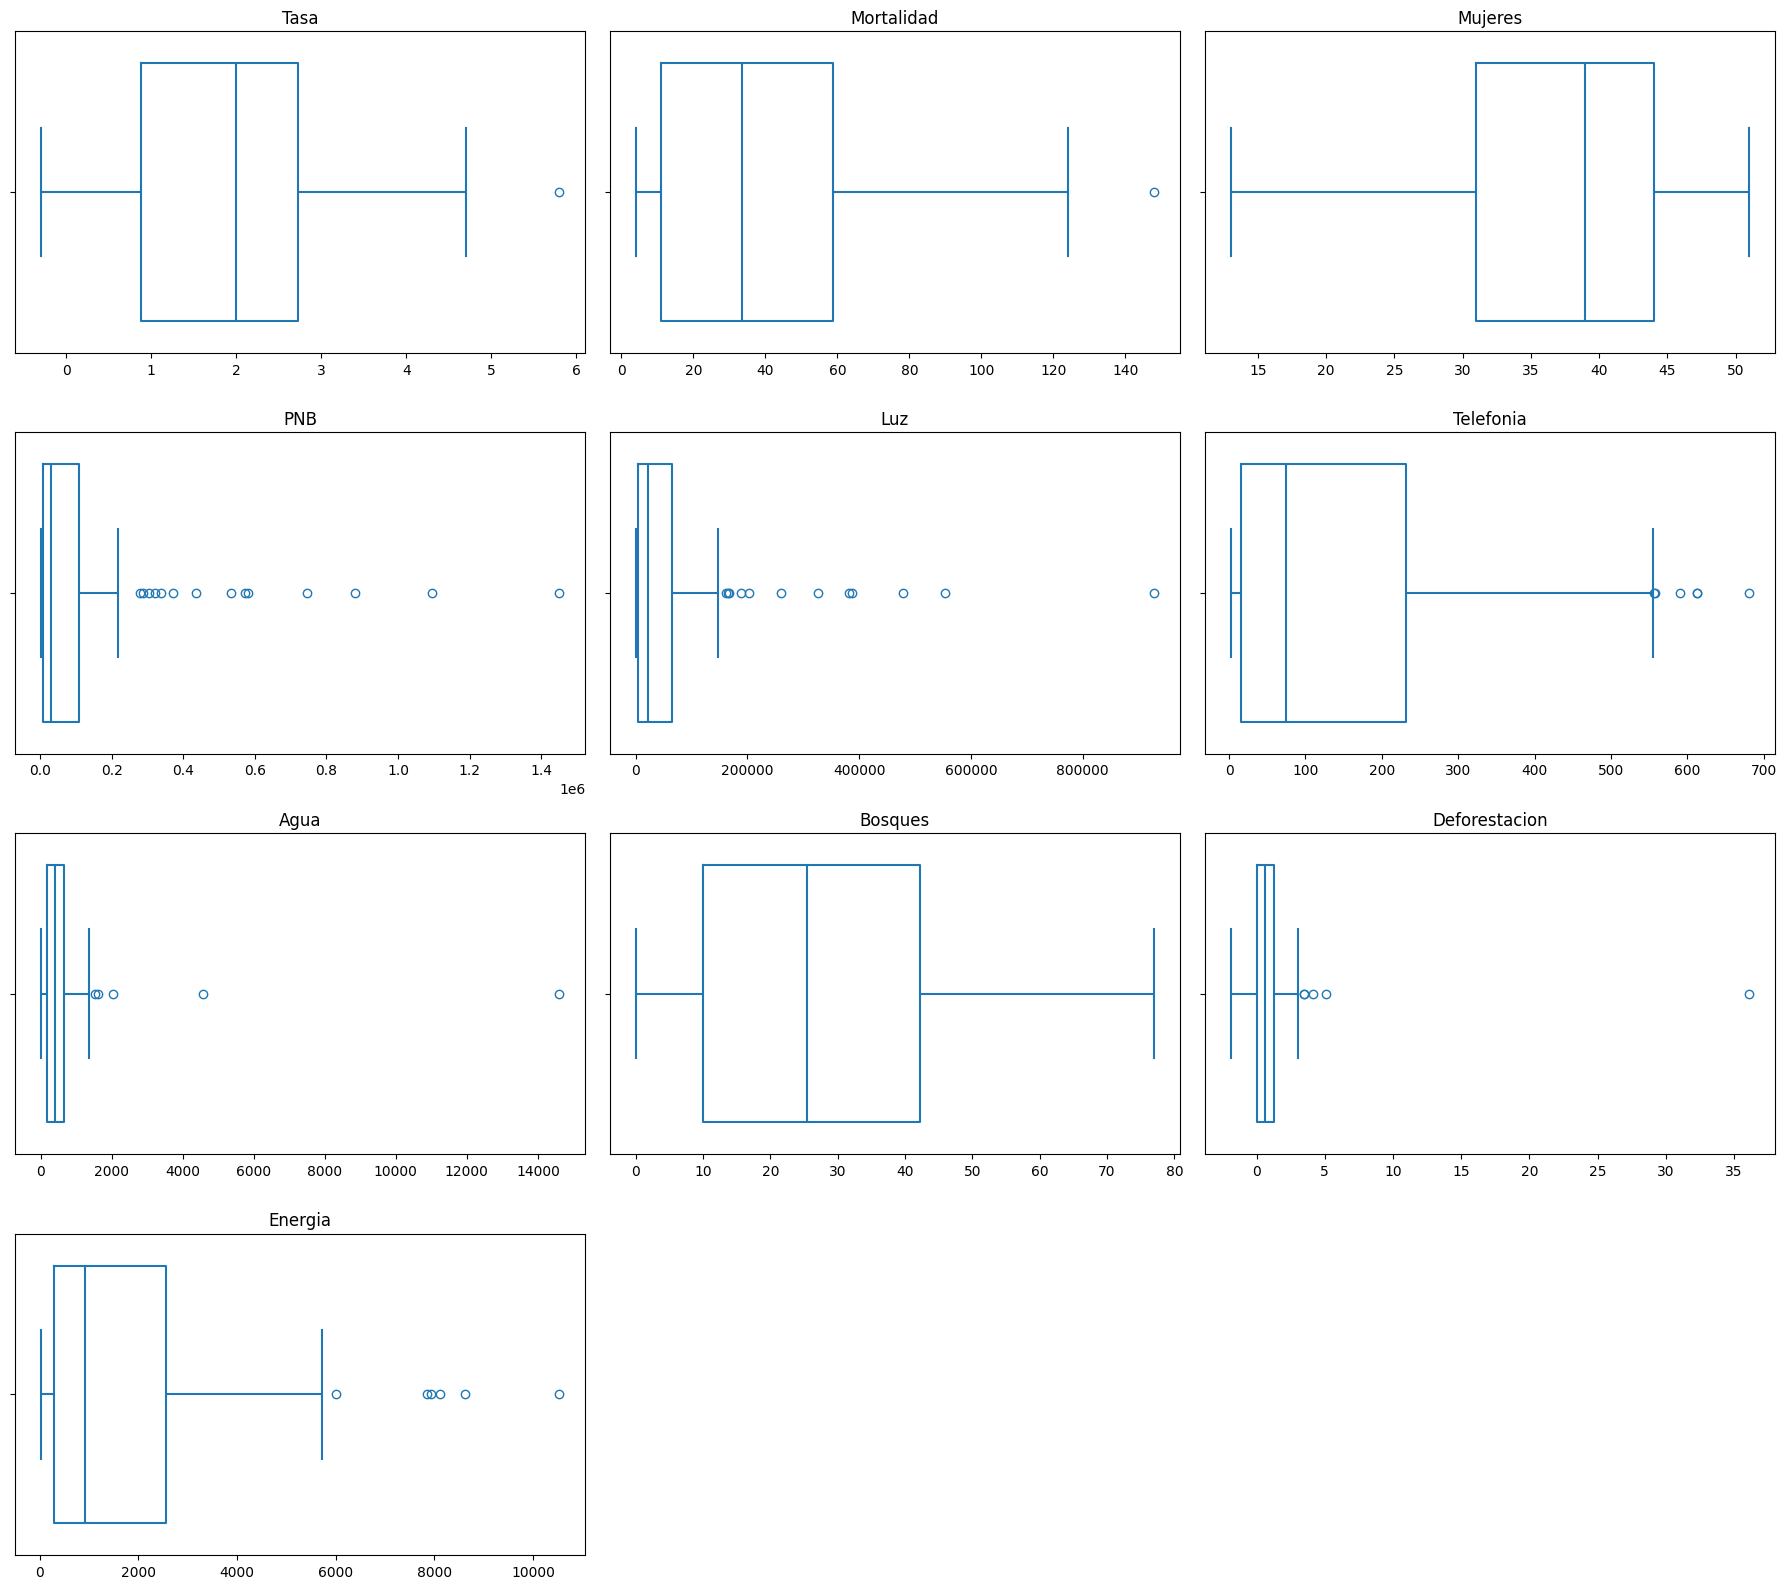

In [ ]:
variables = df.columns[1:11].to_list()

# Ajustar número de columnas y filas automáticamente
n_cols = 3
n_rows = int(np.ceil(len(variables) / n_cols))

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for i, var in enumerate(variables):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[var],fill=False, legend=False)
    plt.title(f'{var}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

Las variables com mayor numero de outliers son `PNB` y `Luz`

In [ ]:
# Correlacion entre variables
corr_matrix = df.iloc[:,1:].corr().reset_index().melt(id_vars='index')
corr_matrix.columns = ['var1', 'var2', 'correlation']

heatmap = alt.Chart(corr_matrix).mark_rect().encode(
    x='var1:O',
    y='var2:O',
    color='correlation:Q',
    tooltip=['var1', 'var2', 'correlation']
).properties(
    width=800,
    height=800
).interactive()

heatmap

alt.Chart(...)

Se puede apreciar una correlacion positiva fuerte de `Energía` con `CO2` y `Telefonía`, asi como una correlación negativa fuerte de `Mortalidad` con las tres anterores.

Debido a la presencia de outliers y que no todas las variables se encuentran en la misma escala se comparara con una visualización TSNE un escalado robusto y logarimoco para observar cual conserva mejor la estrucura de los datos.

In [ ]:
X = df.iloc[:,1:]
X_rs = robust_scale(X)
df_log = df.iloc[:,1:].copy()
df_log['Deforestacion'] = df_log['Deforestacion'].apply(lambda x: x+1.9) # Sumamos el valor minimo en esta variable para evitar errores
X_log = np.log1p(df_log)

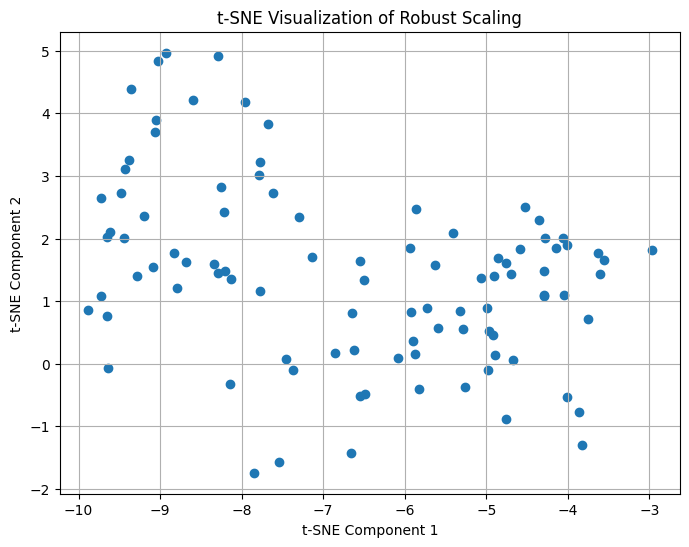

In [ ]:
tsne = TSNE(perplexity=45)
tsne_results_log = tsne.fit_transform(X_rs)
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results_log[:, 0], tsne_results_log[:, 1])
plt.title('t-SNE Visualization of Robust Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

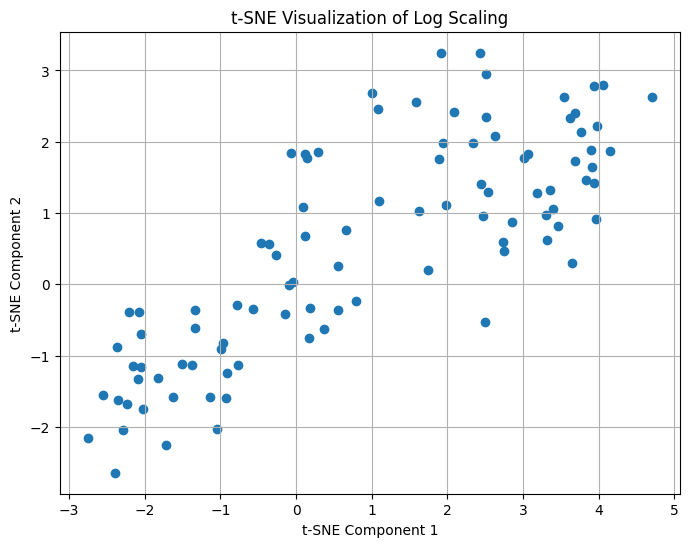

In [ ]:
tsne = TSNE(perplexity=45)
tsne_results_log = tsne.fit_transform(X_log)
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results_log[:, 0], tsne_results_log[:, 1])
plt.title('t-SNE Visualization of Log Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

En apariencia el escalado logaritmico presenta menos dispersión en los datos, siguierendo que es más facil con este escalado la visualización de los clusters.


In [ ]:
df_ln = pd.DataFrame(X_log, columns=df.columns[1:])
df_ln.describe().T

,count,mean,std,min,25%,50%,75%,max
Tasa,96.0,0.961241,0.474093,-0.356675,0.628337,1.098612,1.315000,1.916923
Mortalidad,96.0,3.325475,0.963610,1.609438,2.484907,3.540854,4.089937,5.003946
Mujeres,96.0,3.612619,0.272651,2.639057,3.465736,3.688567,3.806662,3.951244
PNB,96.0,10.374512,1.703951,7.210818,8.988607,10.267106,11.600974,14.187799
Luz,96.0,9.748357,1.956337,1.945910,8.449705,9.970153,11.094138,13.740878
Telefonia,96.0,4.152729,1.600708,1.098612,2.801923,4.317399,5.448828,6.525030
Agua,96.0,5.793283,1.158028,2.079442,5.222956,5.980875,6.504275,9.588982
Bosques,96.0,2.929467,1.113157,0.000000,2.397895,3.276967,3.766947,4.356709
Deforestacion,96.0,1.307193,0.366037,0.000000,1.064711,1.252763,1.435085,3.663562
Energia,96.0,6.614712,1.581145,3.044522,5.663153,6.819427,7.844947,9.262174


In [ ]:
df_rs = pd.DataFrame(X_rs, columns=df.columns[1:])
df_rs.describe().T

,count,mean,std,min,25%,50%,75%,max
Tasa,96.0,-0.059065,0.653951,-1.243243,-0.608108,0.0,0.391892,2.054054
Mortalidad,96.0,0.144852,0.710579,-0.617801,-0.471204,0.0,0.528796,2.397906
Mujeres,96.0,-0.132212,0.674924,-2.000000,-0.615385,0.0,0.384615,0.923077
PNB,96.0,0.925905,2.337314,-0.270879,-0.205066,0.0,0.794934,14.052077
Luz,96.0,0.783374,2.210420,-0.350463,-0.274045,0.0,0.725955,14.837087
Telefonia,96.0,0.421875,0.907366,-0.333333,-0.270833,0.0,0.729167,2.810185
Agua,96.0,0.535147,3.201767,-0.804145,-0.436269,0.0,0.563731,29.444560
Bosques,96.0,0.056848,0.620932,-0.790698,-0.480620,0.0,0.519380,1.596899
Deforestacion,96.0,0.467949,2.884568,-1.923077,-0.461538,0.0,0.538462,27.307692
Energia,96.0,0.414841,0.988319,-0.394792,-0.276619,0.0,0.723381,4.244290


Al comparar las estadśiticas descriptivas se puede observar que con un escalado logaritmico la mayoria de las variables tienen una desviación estandar menor en comparación con el escalado robusto.

Esto es de esperarse ya que el escalado logaritmico es util para estabilizar la varianza de los datos, es por ello que se elige para trabajar con los algoritmos de de clusterización ya que trabajan mejor con datos menos dispersos.

In [ ]:
features = df.columns[1:].to_list()
features

['Tasa',
 'Mortalidad',
 'Mujeres',
 'PNB',
 'Luz',
 'Telefonia',
 'Agua',
 'Bosques',
 'Deforestacion',
 'Energia',
 'CO2']

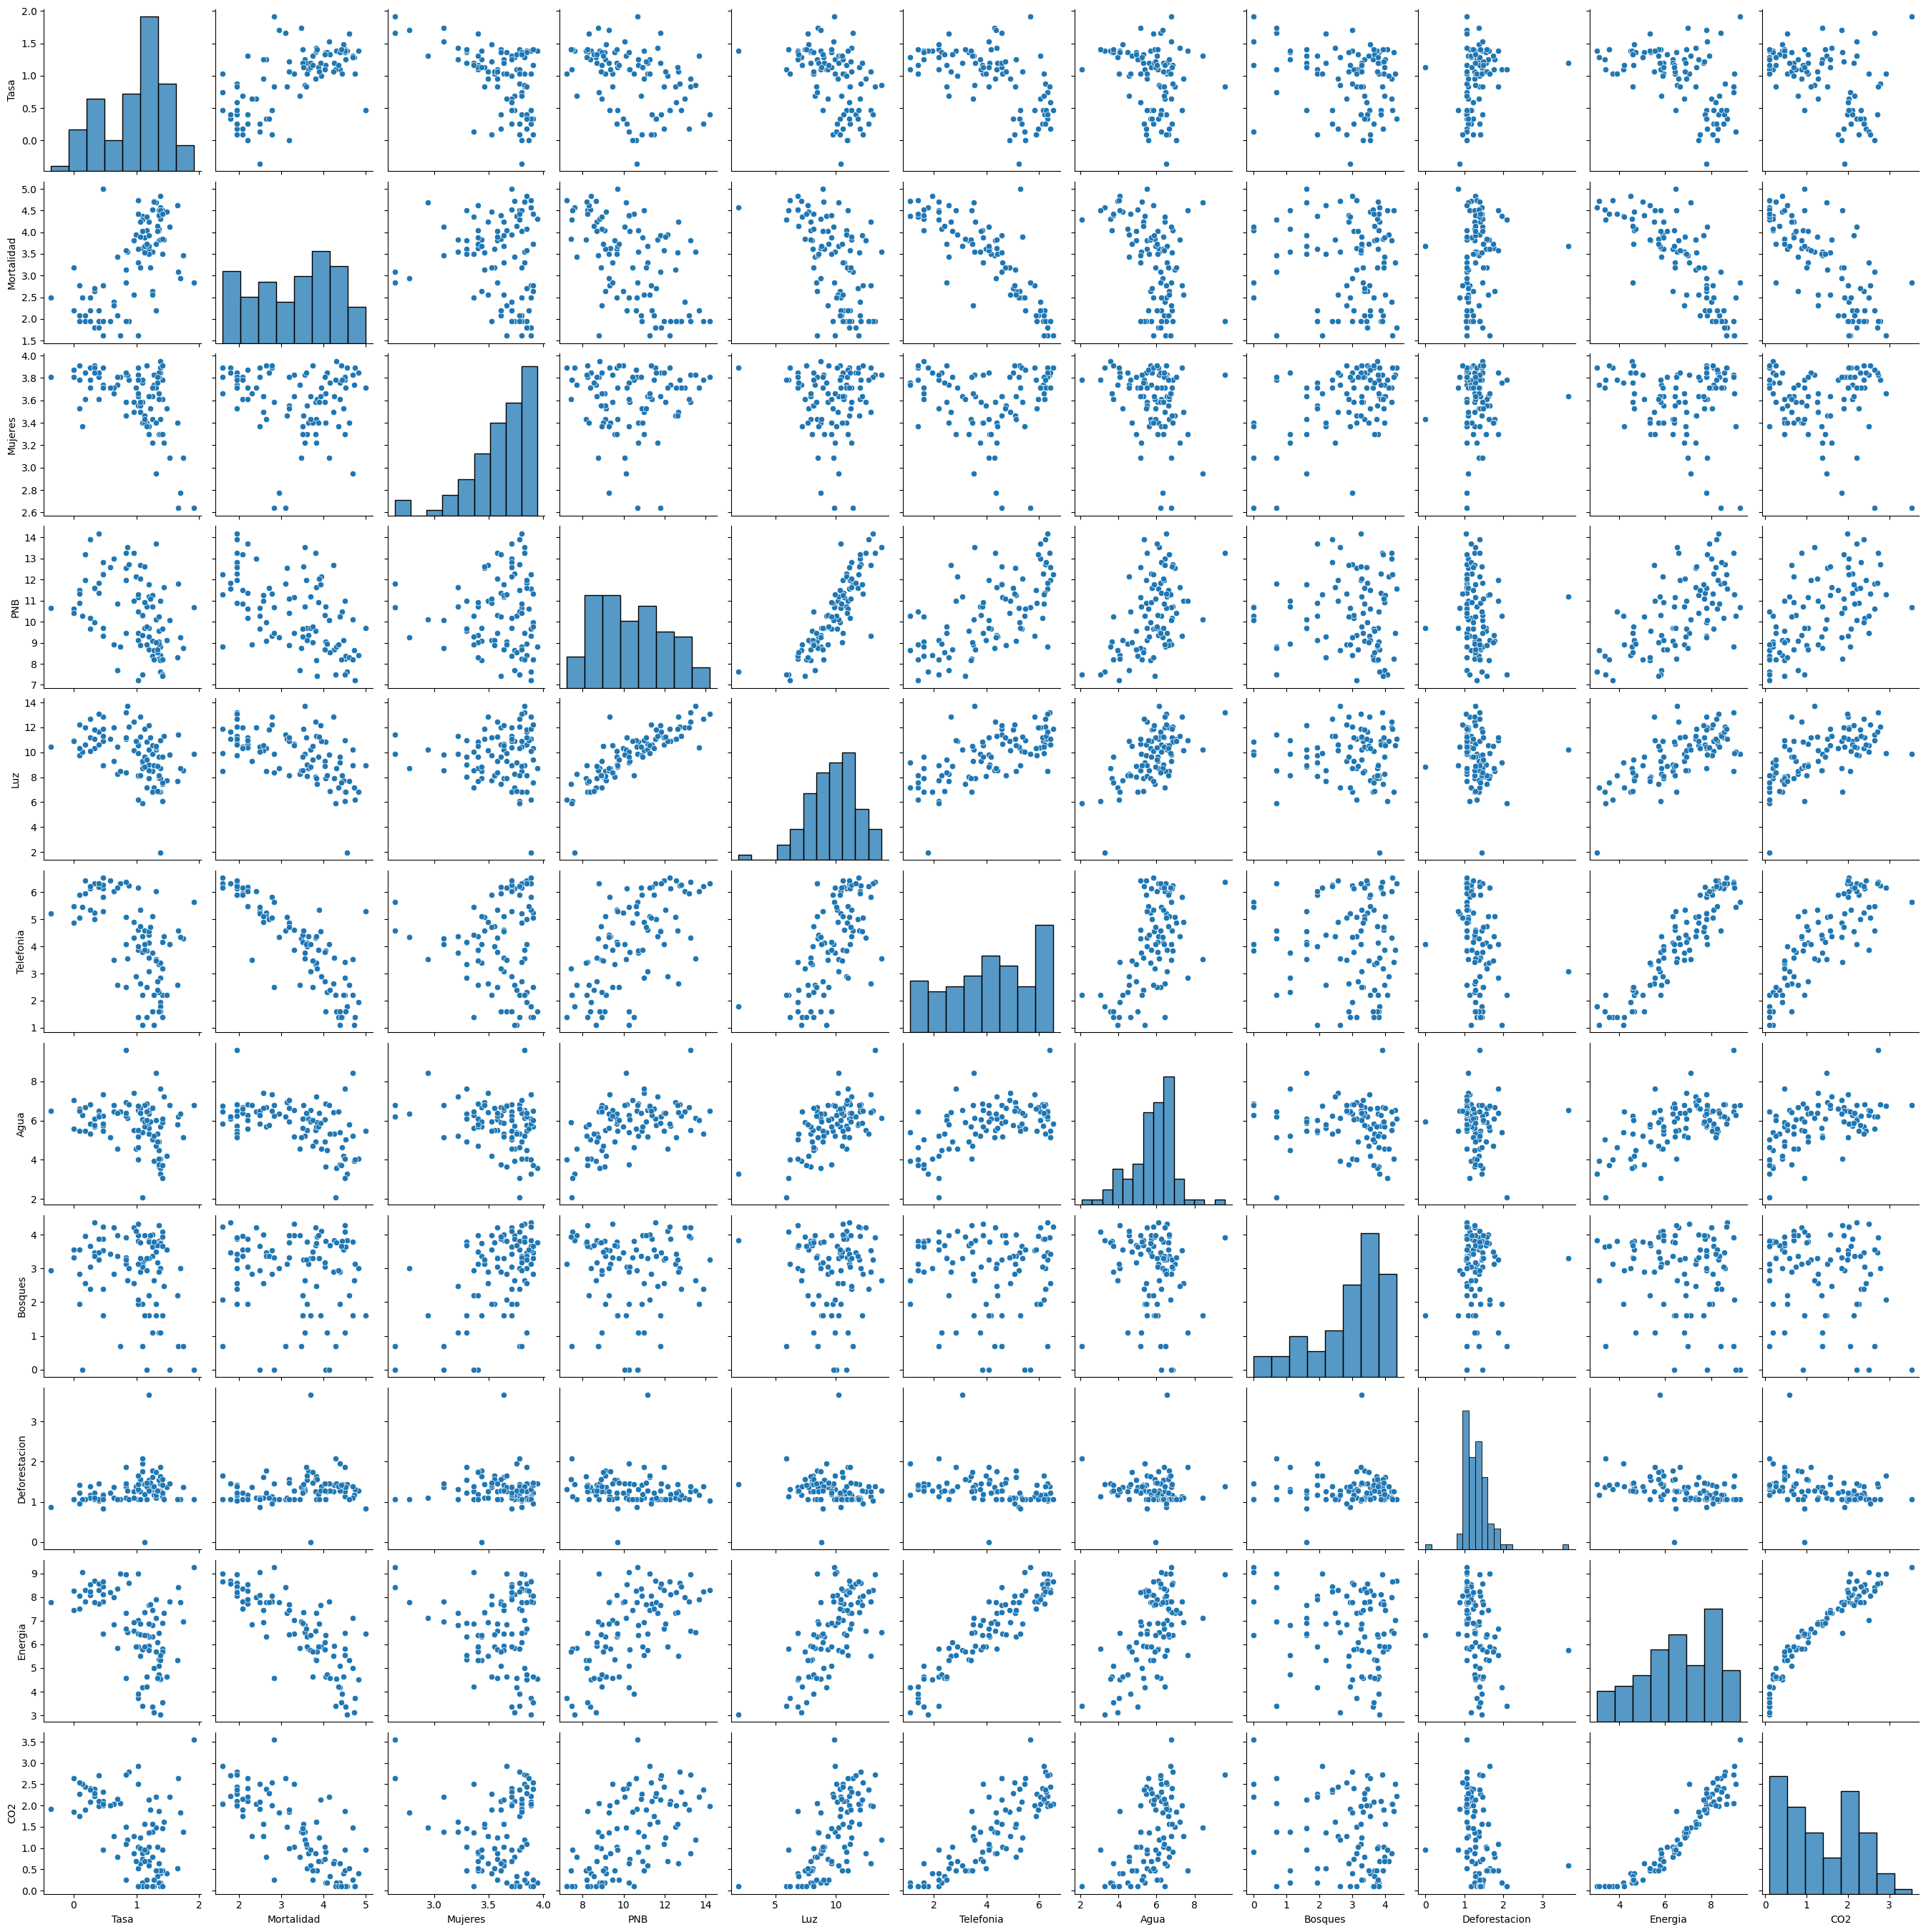

In [ ]:
sns.pairplot(df_ln)

# PCA

In [ ]:
#PCA
pca = PCA(n_components=11)
X_c = pca.fit_transform(X_log)

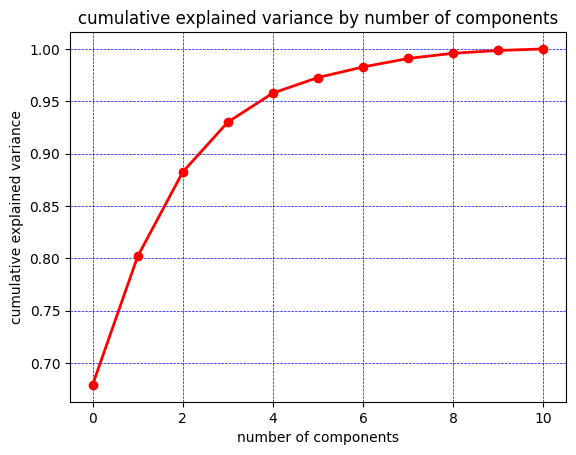

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2)
plt.grid(color = 'blue', linestyle = '--', linewidth = 0.5)
plt.title('cumulative explained variance by number of components')
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.show()

Con 4 componentes se logra explicar cerca del 95% de la variabilidad total.

In [ ]:
pca = PCA(n_components=4)
X_c = pca.fit_transform(X_log)
pd.DataFrame(
    data= pca.components_,
    columns=df_log.columns,
    index=["PC1","PC2","PC3","PC4"])

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
PC1,-0.079243,-0.228586,-0.002878,0.434701,0.526810,0.427698,0.238940,-0.018146,-0.027024,0.430647,0.220077
PC2,0.034373,0.236154,0.029510,0.489372,0.499426,-0.415142,-0.027281,0.226215,0.054843,-0.407681,-0.244530
PC3,-0.147086,-0.236458,0.138676,-0.009536,-0.127282,0.200849,-0.259420,0.882733,-0.004125,-0.006686,0.003456
PC4,0.041866,0.088469,-0.045171,-0.422120,0.147548,-0.085036,0.820366,0.315347,0.040150,-0.012234,-0.083586


💈 Componente 1:

Las variables que mas contribuyen son las relacionadas con la situacion económica del País (`PNB`,`Luz`,`Telefonía` y `Energía`) y la ausencia de la variable `Mortalidad` tambien contribuye en menor medida.

💈 Componente 2:

Para este componente las variables que mas contribuyen son `PNB`,`Luz` relacionadas con el desarrollo de un país.
  
💈 Componente 3:

La variable `Bosques` es la que mayor aporta para esta componente indicando indirectamente el grado de urbanización en el país.
  
💈 Componente 4:

Esta componente tiene la mayor carga en la variable `Agua`, relacionado indirectamente con la cantidad de habitantes del país. Si se añade la población del país podria tambien relacinarse con el grado de industrialización que tiene.

📚

De manera intuitiva se esperaria que al aplicar PCA las cargas de los componentes tuvieran relación entre si para poder clasificarlos de alguna manera, sin embargo esto no ocurre dada la poca correlación existente entre las variables.  

In [ ]:
df

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
0,Albania,1.0,30,41,2199,3903,12,94,53,0.0,341,1.2
1,Angola,3.0,124,46,4422,922,6,57,19,0.7,89,0.5
2,Arabia Saudi,4.3,21,13,133540,91019,96,497,1,0.0,4566,13.1
3,Argelia,2.5,34,24,44609,19883,42,180,2,0.8,906,3.0
4,Argentina,1.3,22,31,278431,65962,160,1043,22,0.1,1504,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...
91,Venezuela,2.4,23,33,65382,73116,111,382,52,1.5,2186,5.7
92,Vietnam,2.2,41,49,17634,12270,11,414,26,1.5,101,0.3
93,Yemen,4.2,100,29,4044,2159,12,335,8,0.0,206,0.7
94,Zambia,2.6,109,45,3605,7785,8,186,43,1.1,149,0.3


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8


# Clustering

In [ ]:
def plot_cluster(X, labels):
    fig, ax = plt.subplots(1,figsize=(8,6))
    scatter = ax.scatter(x=X[:,0],
               y=X[:,1],
               c = labels,
               edgecolor = 'black')
    legend = ax.legend(*scatter.legend_elements(),
                    loc="lower left", title="Clusters")
    ax.add_artist(legend)
    ax.set_title('Gráfico PCA')
    return fig, ax

Para todos los algoritmos se eligió una transformación logarítmica, pues pone los datos en una escala similar.  

## K-means


Text(0, 0.5, 'Media de Silhouette')

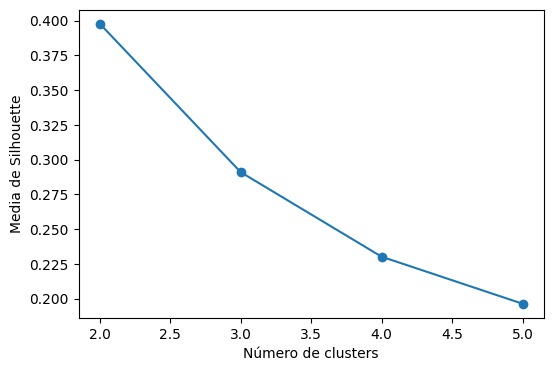

In [ ]:
# Una manera de encontrar el número óptimo de clusters es mediante el coeficiente de Shilouette
from sklearn.metrics import silhouette_score, silhouette_samples

rango = range(2,6) #probamos el número de clusters de 2 a 6
valores_medios = []
for k in rango:
  kmedias = KMeans(n_clusters=k, random_state=123)
  etiquetas = kmedias.fit_predict(X_log)
  valores_m = silhouette_score(X_log, etiquetas) # El coeficiente necesita los datos y las etiquetas de los clusters
  valores_medios.append(valores_m)

# Gráfico de estos coeficienes donde lo que buscamos es el valor máximo
fig, ax = plt.subplots(1,1,figsize = (6,4))
ax.plot(rango, valores_medios, marker='o')
ax.set_xlabel('Número de clusters')
ax.set_ylabel('Media de Silhouette')

Utilizando el coeficente de silhouette se observa que el numero de clústers optimos es de 2

In [ ]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_log)

KMeans(n_clusters=2)

In [ ]:
labels = kmeans.fit_predict(X_log)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Gráfico PCA'}>)

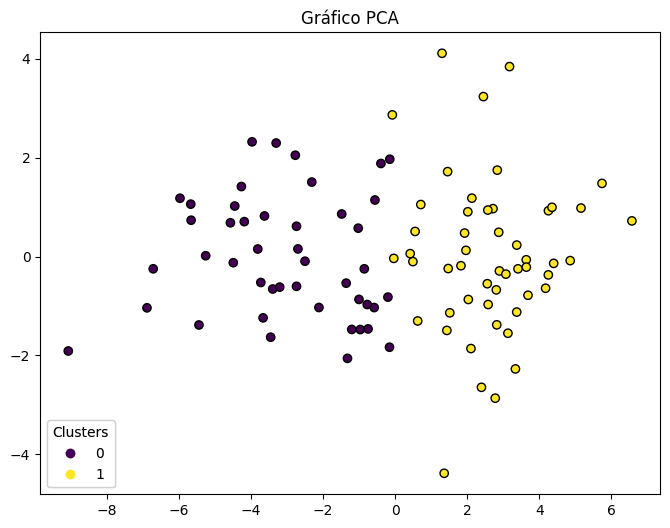

In [ ]:
plot_cluster(X_c, labels)

In [ ]:
df['Kmeans']=labels
df[features+['Kmeans']].groupby('Kmeans').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
Kmeans,,,,,,,,,,,
0,1.321765,21.117647,38.019608,218820.098039,123906.254902,281.254902,957.588235,27.235294,0.486275,3175.215686,7.600000
1,2.535556,62.288889,36.444444,13306.155556,7396.333333,33.511111,308.244444,27.444444,2.026667,357.533333,1.102222


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,Kmeans
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,0


---
***Características Clúster 0:***
---

*   **Económicas :**  En este grupo se encuentran los paises con un `PNB` alto, una producción y consumo de energía elevados y alrededor del 28% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises desarrollados.
*   **Sociales :** Observamos una baja `Mortalidad` cerca del 2% de cada 1000 nacimientos pero un incremento poblacional bajo `Tasa`. Sobreviven mas niños pero posiblemente nacen menos en estos paises.
*   **Ambientales :** Se nota un alto valor en `CO2` y una `Deforestacion` moderada indicando que posiblemente estos paises tengan una industria grande.


---
***Características Clúster 1:***
---

*   **Económicas :** Aquí encontramos a paises con numeros extremandamente mas bajos en comparación con el otro clúster, tratandose de paises con un bajo nivel de desarrollo o paises pequeños.
*   **Sociales :** Se observa una alta tasa de `Mortalidad`, pero contradictoriamente una moderadamente elevada `Tasa`, una explicación posible sea que en estos paises existe un flujo migratorio considerado o una alta tasa de natalidad.  
*   **Ambientales :** Se observa un nivel muy bajo de `CO2` en conjunto con un nivel de `Agua`levemente bajo, se deba a la poca población y la baja industrialización de estos paises.

---

In [ ]:
def plot_social (df,cluster):

  cls = cluster+':N'
  #Search_Box
  search_box = alt.param(
      value='',
      bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
  )
  # Valores encontrados
  search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
  # definir la opacidad de los valores
  opacity = (
      alt.when(search_matches)
      .then(alt.value(0.9))
      .otherwise(alt.value(0.2))
  )
  # Crear el gráfico
  chart = alt.Chart(df).mark_point().encode(
      x=alt.X('Tasa:Q', title='Tasa de crecimiento poblacional'),
      y=alt.Y('Mujeres:Q', title='% Mujeres Económicamente Activas'),
      size=alt.Size('Mortalidad:Q', title="Mortalidad"),
      color=alt.Color(cls, legend=alt.Legend(title="Clusters")),
      opacity=opacity,
      tooltip=['Pais','PNB', 'Luz', 'Telefonia','Agua','Bosques','Deforestacion','Energia','CO2']
  ).properties(
      width=900,
      height=600,
      title={
        "text": 'Condiciones Sociales por Cluster',
        "subtitle": 'Tamaño proporcional a Mortalidad'
      }
  ).add_params(
      search_box
  ).interactive()

  return chart.show()

plot_social(df, 'Kmeans')


alt.Chart(...)

In [ ]:
# Social Graph

#Search_Box
search_box = alt.param(
    value='',
    bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
)
search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
opacity = (
    alt.when(search_matches)
    .then(alt.value(0.9))
    .otherwise(alt.value(0.2))
)
alt.Chart(df).mark_point().encode(
    x=alt.X('Tasa:Q', title='Tasa de natalidad'),
    y=alt.Y('Mujeres:Q', title='% Mujeres Económicamente Activas'),
    size=alt.Size('Mortalidad:Q', title="Mortalidad"),
    color=alt.Color('Kmeans:N', legend=alt.Legend(title="Clusters")),
    opacity=opacity,
    tooltip=['Pais','PNB', 'Luz', 'Telefonia','Agua','Bosques','Deforestacion','Energia','CO2']
).properties(
    width=900,
    height=600,
    title={
      "text": 'Condiciones Sociales por Cluster',
      "subtitle": 'Tamaño proporcional a Mortalidad'
    }
).add_params(
    search_box
).interactive()

alt.Chart(...)

In [ ]:
def plot_econ (df,cluster):

  cls = cluster+':N'
  #Search_Box
  search_box = alt.param(
      value='',
      bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
  )
  search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
  opacity = (
      alt.when(search_matches)
      .then(alt.value(0.9))
      .otherwise(alt.value(0.2))
  )
  chart = alt.Chart(df).mark_point().encode(
      x=alt.X('PNB:Q', title='Producto Nacional Bruto',scale=alt.Scale(type='log', base=10)),
      y=alt.Y('Luz:Q', title='Producción de Electricidad',scale=alt.Scale(type='log', base=10)),
      size=alt.Size('Telefonia:Q', title="Telefonia per capita"),
      color=alt.Color(cls, legend=alt.Legend(title="Clusters")),
      opacity=opacity,
      tooltip=['Pais','Tasa','Mortalidad', 'Mujeres','Agua','Bosques','Deforestacion','Energia','CO2']
  ).properties(
      width=900,
      height=600,
      title={
        "text": 'Condiciones Económicas por Cluster',
        "subtitle": 'Tamaño proporcional a Lineas Telefonicas '
      }
  ).add_params(
      search_box
  ).interactive()

  return chart.show()

plot_econ(df, 'Kmeans')

alt.Chart(...)

In [ ]:
# Economics Graph

#Search_Box
search_box = alt.param(
    value='',
    bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
)
search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
opacity = (
    alt.when(search_matches)
    .then(alt.value(0.9))
    .otherwise(alt.value(0.2))
)
alt.Chart(df).mark_point().encode(
    x=alt.X('PNB:Q', title='Producto Nacional Bruto',scale=alt.Scale(type='log', base=10)),
    y=alt.Y('Luz:Q', title='Producción de Electricidad',scale=alt.Scale(type='log', base=10)),
    size=alt.Size('Energia:Q', title="Energía per capita"),
    color=alt.Color('Kmeans:N', legend=alt.Legend(title="Clusters")),
    opacity=opacity,
    tooltip=['Pais','PNB', 'Luz', 'Telefonia']
).properties(
    width=900,
    height=600,
    title={
      "text": 'Condiciones Económicas por Cluster',
      "subtitle": 'Tamaño proporcional a Consumo de Energía'
    }
).add_params(
    search_box
).interactive()

alt.Chart(...)

In [ ]:
def plot_env (df,cluster):

  cls = cluster+':N'
  #Search_Box
  search_box = alt.param(
      value='',
      bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
  )
  search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
  opacity = (
      alt.when(search_matches)
      .then(alt.value(0.9))
      .otherwise(alt.value(0.2))
  )
  chart = alt.Chart(df).mark_point().encode(
      x=alt.X('Deforestacion:Q', title='Tasa anual de Deforestación'),
      y=alt.Y('Bosques:Q', title='Proporción de la superficie cubierta por Bosques'),
      size=alt.Size('CO2:Q', title="CO2 per capita"),
      color=alt.Color(cls, legend=alt.Legend(title="Clusters")),
      opacity=opacity,
      tooltip=['Pais','Tasa','Mortalidad', 'Mujeres','PNB', 'Luz', 'Telefonia','Energia','Agua']
  ).properties(
      width=900,
      height=600,
      title={
        "text": 'Condiciones Ambientales por Cluster',
        "subtitle": 'Tamaño proporcional a CO2'
      }
  ).add_params(
      search_box
  ).interactive()

  return chart.show()

plot_env(df, 'Kmeans')

alt.Chart(...)

In [ ]:
# Enviroment Graph

#Search_Box
search_box = alt.param(
    value='',
    bind=alt.binding(input='search', placeholder="Pais", name='Buscar ')
)
search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.Pais)
opacity = (
    alt.when(search_matches)
    .then(alt.value(0.9))
    .otherwise(alt.value(0.2))
)
alt.Chart(df).mark_point().encode(
    x=alt.X('Bosques:Q', title='Proporción de la superficie cubierta por Bosques'),
    y=alt.Y('Deforestacion:Q', title='Tasa anual de Deforestación'),
    size=alt.Size('Agua:Q', title="Consumo de Agua"),
    color=alt.Color('Kmeans:N', legend=alt.Legend(title="Clusters")),
    opacity=opacity,
    tooltip=['Pais','PNB', 'Luz', 'Telefonia']
).properties(
    width=900,
    height=600,
    title={
      "text": 'Condiciones Ambientales por Cluster',
      "subtitle": 'Tamaño proporcional a Agua'
    }
).add_params(
    search_box
).interactive()

alt.Chart(...)

## Aglomerativos

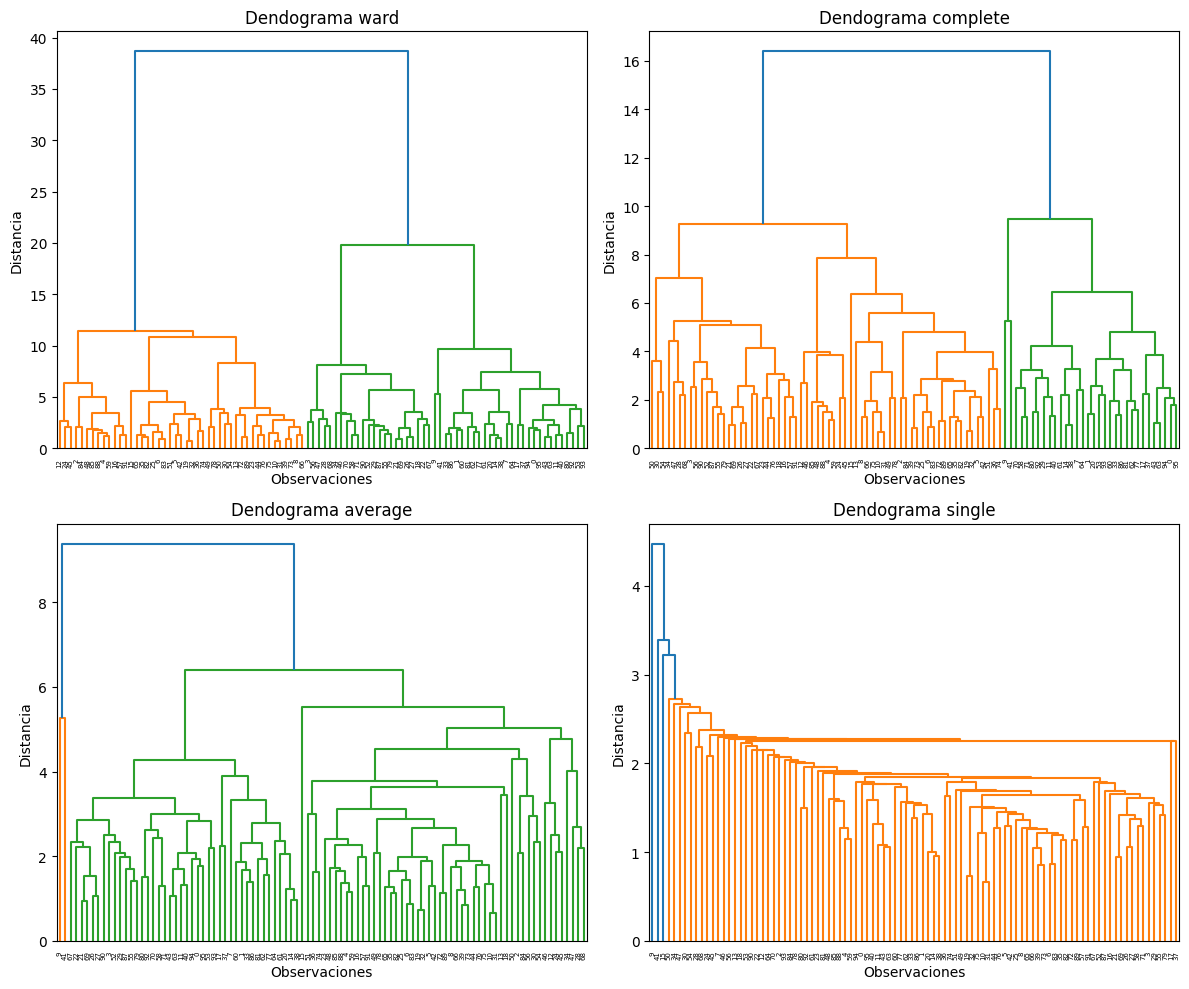

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']

plt.figure(figsize=(12, 10))

for method in linkage_methods:
    plt.subplot(2, 2, linkage_methods.index(method) + 1)
    dendrogram = sch.dendrogram(sch.linkage(X_log, method=method))
    plt.title('Dendograma '+ method)
    plt.xlabel('Observaciones')
    plt.ylabel('Distancia')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Media de Shilouette')

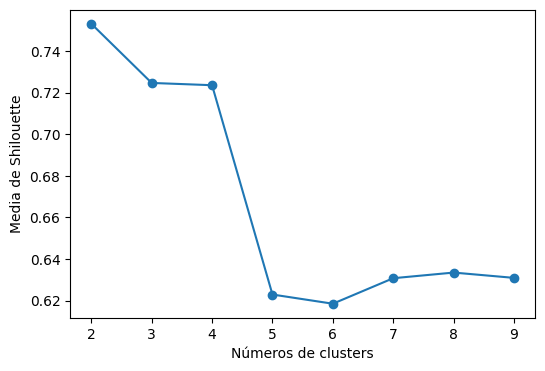

In [ ]:
rango=range(2,10) #probamos el número de clusters de 2 hasta 10
valores_medios=[]

for n_clusters in rango:
    aglom=AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    etiquetas=aglom.fit_predict(X)
    valores_m=silhouette_score(X,etiquetas)  #El coeficiente necesita los datos y las etiquetas de los clusters
    valores_medios.append(valores_m)

#Gráfico de estos coeficientes donde lo que buscamos es el valor máximo.
fig, ax=plt.subplots(1,1,figsize=(6,4))
ax.plot(rango,valores_medios,marker='o')
ax.set_xlabel("Números de clusters")
ax.set_ylabel("Media de Shilouette")

Mediante el dendograma en la mayoria de ellos el numero aproximado de clústers es de 2 y al obtener el coeficiente de silhouette se observa que 3 o 4 tambien pueden considerarse.
De todos los dendogramas, el metodo de linkage ward es en el cual es mas apreciable los 3 clusters en un corte alrededor de 15.

In [ ]:
# Modelo aglomerativo

aglom = AgglomerativeClustering(n_clusters=3, linkage='ward')
# Asignaciones
labels = aglom.fit_predict(X_log)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Gráfico PCA'}>)

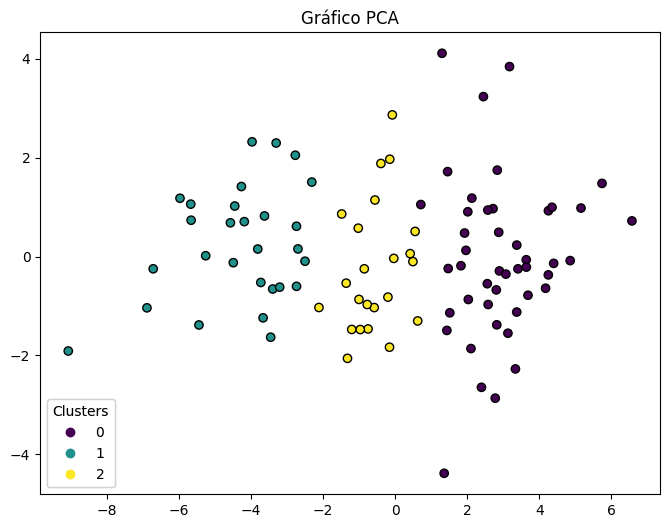

In [ ]:
plot_cluster(X_c, labels)

In [ ]:
df['Agglo']=labels
df[features+['Agglo']].groupby('Agglo').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
Agglo,,,,,,,,,,,
0,1.175778,16.466667,39.155556,240416.311111,135802.555556,313.333333,921.400000,27.755556,0.475556,3449.400000,7.986667
1,2.617857,74.178571,40.464286,8498.428571,3622.107143,10.642857,162.678571,32.321429,1.232143,161.107143,0.657143
2,2.404348,46.173913,29.739130,30517.913043,19109.565217,63.217391,725.652174,20.434783,2.613043,795.260870,2.582609


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')[['Pais']+features+['Agglo']]

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,Agglo
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,0


---
***Características Clúster 0:***
---

*   **Económicas :**  En este grupo se encuentran los paises con los más altos niveles de `PNB`, `Luz`, `Energia` y alrededor del 31% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises desarrollados., donde la mayor parte de la población se concentra en ciudades grandes.
*   **Sociales :** Notamos que la `Tasa` y la `Mortalidad` son los valores más bajos en comparación con los demas clusters, además de un moderado porcentaje de `Mujeres`. Esto parece indicar que hay pocos nacimientos en estos paises.   
*   **Ambientales :** En este apartado se cuenta con una baja `Deforestacion`, pero los niveles de `CO2`mas altos, reflejando un alto grado de industrialización conservando la mayor cantidad de bosques posible.

---
***Características Clúster 1:***
---

*   **Económicas :** Aquí encontramos a paises con numeros extremandamente mas bajos en comparación con el otro clúster,solo el 1% de cada 1000 habitantes cuenta con medio de comunicación,  tratandose de paises con un bajo nivel de desarrollo o paises pequeños.
*   **Sociales :**Observamos el mayor nivel de `Mujeres` y de `Mortalidad`, generando una preocupación alarmante ya que este tipo de paises cuentan con acceso a la salud muy bajo.
*   **Ambientales :** Se muestra el nivel más bajo de `CO2`, pero un elevado nivel de `Deforestacion`. El bajo nivel de `Agua`y el alto nivel de `Bosques`sugiere areas poco urbanizadas y posiblemente con poca infraestructura para la distribución del Agua.

---
***Características Clúster 2:***
---

*   **Económicas :** Aquí se agrupan los paises con niveles intermedios, tratandose de paises en vias de desarrollo.
*   **Sociales :**  Estos paises tiene el nivel más bajo de `Mujeres` y una moderadamente alta `Tasa`, indicando un escenario preocuante el cual podria perpetual los ciclos de pobreza.  
*   **Ambientales :** Estos paises tienen promedio la `Deforestacion` más alta y la proporcion de `Bosques` más baja, en conjunto estas variables indican que las zonas de urbanización se centran en lugares cercanos a los bosques.

---

In [ ]:
plot_social(df, 'Agglo')

alt.Chart(...)

In [ ]:
plot_econ(df, 'Agglo')

alt.Chart(...)

In [ ]:
plot_env(df, 'Agglo')

alt.Chart(...)

## DBSCAN

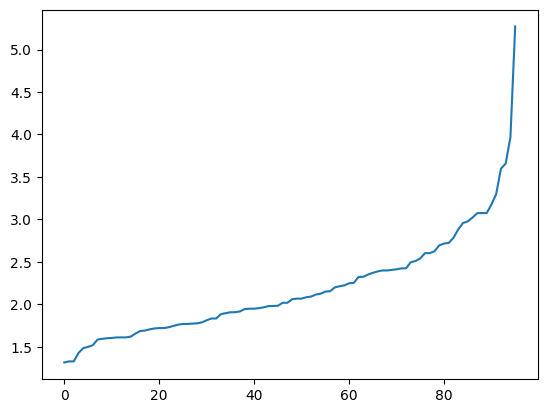

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_log)
distances, indices = nbrs.kneighbors(X_log)
sort_distances = np.sort(distances, axis=0)
k_dist = sort_distances[:,4]
plt.plot(k_dist)


Utilizando el metodo del codo se aprecia que con un valor epsilon de 2, se obtendrian el número de clúster optimo.  

In [ ]:
#Algoritmo DBSCAN
dbs = DBSCAN(eps=2, min_samples=5).fit(X_log)
labels = dbs.labels_
# Número de clústers y numero de outliers
clusters = len(set(labels))-(1 if -1 in labels else 0)
outliers = list(labels).count(-1)
print(f"Número de clústers: {clusters}")
print(f"Número de outliers: {outliers}")


Número de clústers: 2
Número de outliers: 31


Text(0.5, 1.0, 'Cluster generados')

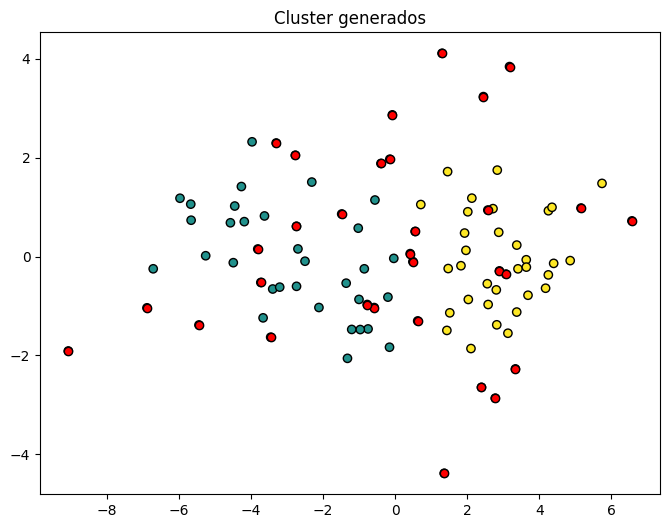

In [ ]:
# Gráfica de las formas

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.scatter(x=X_c[:,0],
           y=X_c[:,1],
           c = labels,
           edgecolor = 'black')
#coloquemos dentro del grafico un color rojo a los outliers
ax.scatter(
    x = X_c[labels==-1,0],
    y = X_c[labels==-1,1],
    c = 'red',
    edgecolor = 'black',
    label = 'outliers'
)
ax.set_title('Cluster generados')

In [ ]:
df['DBS']=labels
df[features+['DBS']].groupby('DBS').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
DBS,,,,,,,,,,,
-1,2.203548,51.193548,35.806452,138636.258065,114487.258065,124.935484,1092.483871,21.096774,2.151613,2175.903226,5.367742
0,2.587500,57.218750,35.250000,12151.781250,5464.718750,36.406250,274.875000,28.812500,1.100000,403.218750,1.150000
1,0.921212,14.000000,40.636364,214303.666667,88729.636364,327.696970,607.424242,31.757576,0.427273,2959.666667,7.090909


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')[['Pais']+features+['DBS']]

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,DBS
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,1


---
***Características Clúster 0:***
---

*   **Económicas :**  En este grupo se encuentran los paises con un `PNB` bajo, una producción y consumo de energía demasiao inferior a los otros y alrededor del 4% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises con un bajo nivel de desarrollo
*   **Sociales :** Este clúster agrupa a los paises con una elevada `Mortalidad` y la más alta `Tasa`, propios de paises en vias de desarrollo.  
*   **Ambientales :** Observamos el nivel mas bajo de `CO2` y una moderada cantidad de `Bosques`, probablemente se trate de paises con zonas aridas.  


---
***Características Clúster 1:***
---

*   **Económicas :** Aquí encontramos a paises un moderado nivel de `PNB`, `Luz`y `Energia`, además de que alrededor del 32% de cada 1000 habitantes cuentan con acceso a una `Telefonia`. Agrupan a paises con un nivel de desarrollo moderado.  
*   **Sociales :** En este clúster se observa un alto nivel de `Mujeres` y los niveles mas bajos de `Tasa`y `Mortalidad`, sugiriendo una probable inversion en la piramide poblacional.
*   **Ambientales :** En este grupo se cuenta con la cantidad más alta de `CO2`
, una baja tasa de `Deforestacion` y un alto nivel de `Bosques`, indicando que posiblemente sean paises con una alta conciencia ambiental.  
---

***Características Clúster -1 (Outliers):***
---

*   **Económicas :** Aquí encontramos a paises con una alta producción de `Luz` y un elevado `PNB` sugirendo que son pasises con un nivel de desarrollo medio-alto.
*   **Sociales :** Se observa una baja proporción de `Mujeres`  y altos niveles de `Tasa`y `Mortalidad`, indicando que es probable que el crecimiento poblacional se deba a flujos migratorios hacia este pais.  
*   **Ambientales :** Este clúster es el que presenta la mayor cantidad de `Agua` junto con altos niveles de `Deforestacion` y `CO2` elevados, mostrando un posible crecimiento urbano.

---

In [ ]:
plot_econ(df, 'DBS')

alt.Chart(...)

In [ ]:
plot_social(df, 'DBS')

alt.Chart(...)

In [ ]:
plot_env(df, 'DBS')

alt.Chart(...)

## GMM

In [ ]:
# GMM on Log-transformed data
gmm_results = []

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    for n in range(2, 9):
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=cov_type,
            random_state=42
        )
        labels = gmm.fit_predict(X_log)

        bic = gmm.bic(X_log)
        aic = gmm.aic(X_log)
        sil = silhouette_score(X_log, labels)

        gmm_results.append({
            'Data': 'Log_transfrom',
            'covariance_type': cov_type,
            'n_components': n,
            'BIC': bic,
            'AIC': aic,
            'Silhouette': sil
        })

gmm_results = pd.DataFrame(gmm_results).sort_values('BIC')
gmm_results.head(10)

,Data,covariance_type,n_components,BIC,AIC,Silhouette
9,Log_transfrom,tied,4,2150.989141,1861.217795,0.143350
8,Log_transfrom,tied,3,2171.899431,1912.900264,0.261987
10,Log_transfrom,tied,5,2178.681510,1858.137986,0.156130
12,Log_transfrom,tied,7,2184.792118,1802.704238,0.146272
7,Log_transfrom,tied,2,2188.438735,1960.211746,0.364096
11,Log_transfrom,tied,6,2209.536769,1858.221067,0.167906
13,Log_transfrom,tied,8,2234.925189,1822.065130,0.130895
0,Log_transfrom,full,2,2255.186965,1857.712996,0.375712
15,Log_transfrom,diag,3,2286.187218,2111.811541,0.268644
16,Log_transfrom,diag,4,2288.687236,2055.331550,0.185202


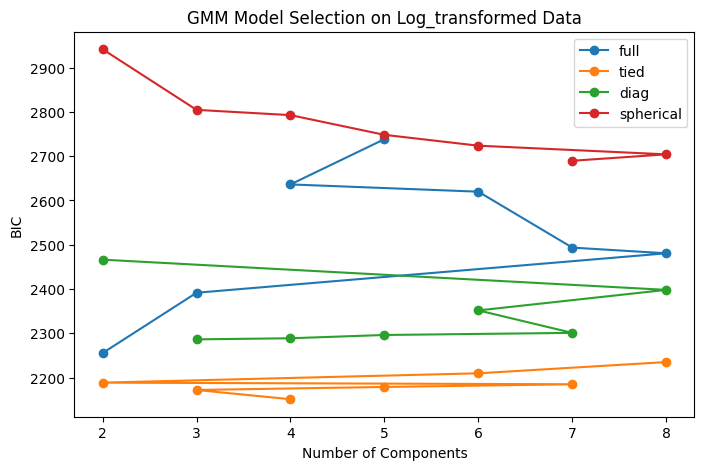

In [ ]:
plt.figure(figsize=(8,5))

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    temp = gmm_results[gmm_results['covariance_type'] == cov_type]
    plt.plot(temp['n_components'], temp['BIC'], marker='o', label=cov_type)

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM Model Selection on Log_transformed Data")
plt.legend()
plt.show()

Se observa que el tipo de covarianza mas bajo es el de tied y los valores de BIC son similares, es por ello que se elige al que tiene un coeficiente de silhouette mas alto.

In [ ]:
gmm = GaussianMixture(n_components=2, covariance_type='tied').fit(X_log)
labels = gmm.predict(X_log)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Gráfico PCA'}>)

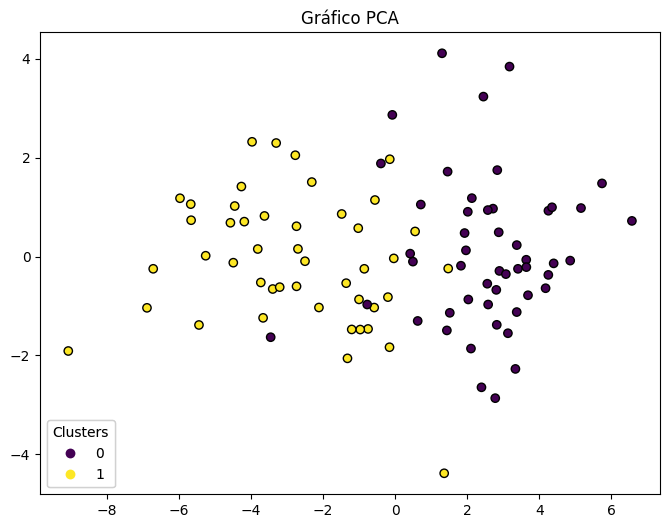

In [ ]:
plot_cluster(X_c, labels)

In [ ]:
df['GMM']=labels
df[features+['GMM']].groupby('GMM').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
GMM,,,,,,,,,,,
0,1.316200,24.94000,38.620000,221919.080000,125058.900000,276.32000,928.460000,29.500000,1.200000,3061.660000,7.632000
1,2.515217,57.23913,35.826087,14405.391304,8676.282609,44.26087,354.021739,24.978261,1.217391,542.217391,1.208696


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')[['Pais']+features+['GMM']]

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,GMM
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,0


---
***Características Clúster 0:***
---

*   **Económicas :**  En este grupo se encuentran los paises con un `PNB` alto, una producción y consumo de energía elevados y alrededor del 28% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises desarrollados.
*   **Sociales :** Observamos niveles bajos de  de `Mortalidad` y `Tasa`, esto se deba probablemente a menos nacimientos y una población envejecida.
*   **Ambientales :** Tenemos el mayor valor de `CO2` y un alta nivel de `Agua` siguirendo ciudades densamente pobladas en la mayoria de estos paises.


---
***Características Clúster 1:***
---

*   **Económicas :** En este grupo se encuentran los paises con un `PNB` bajo, una producción y consumo de energía escasos y alrededor del 4.5% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises en vias de desarrollo.
*   **Sociales :** Se observa una elevada `Mortalidad` al igual que una moderadamente alta `Tasa` y pocas oportunidades laborales para las mujeres. Una posible explicación seria que la mayoria de estos paises cuentan con una alta tasa de natalidad.
*   **Ambientales :** Notamos los niveles más bajos en `CO2` y `Agua` indicando poblaciones pequeñas o con poca infraestructura para el consumo de agua potable.

---


In [ ]:
plot_econ(df, 'GMM')

alt.Chart(...)

In [ ]:
plot_social(df, 'GMM')

alt.Chart(...)

In [ ]:
plot_env(df, 'GMM')

alt.Chart(...)

## Affinity Propagation

Al diminuir el parametro de preference y aumentar el parametro de damping se generan clúesters más precisos.

In [ ]:
# Algoritmo
af = AffinityPropagation(preference= -500, damping=0.7).fit(X_log)

#Parametros por default preference = mediana y dampingfactor =0.5
print("El numero de clusters generados es: ", len(af.cluster_centers_indices_))
print("El número de iteraciones es ; ", af.n_iter_)

El numero de clusters generados es:  2
El número de iteraciones es ;  25


In [ ]:
#Etiquetas
labels = af.predict(X_log)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Gráfico PCA'}>)

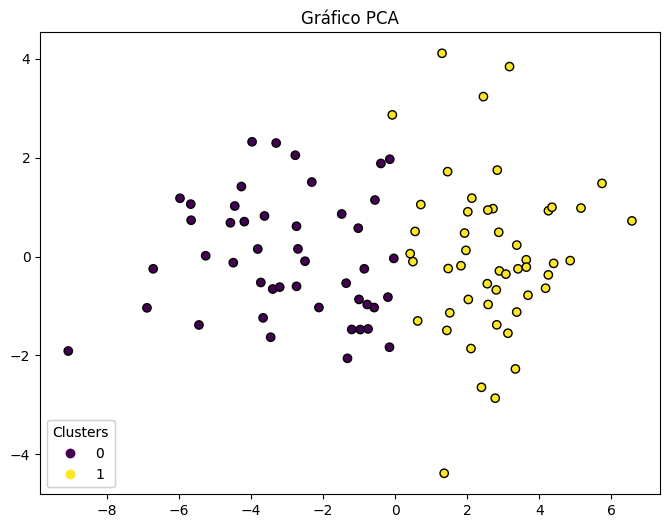

In [ ]:
plot_cluster(X_c, labels)

In [ ]:
df['AF']=labels
df[features+['AF']].groupby('AF').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
AF,,,,,,,,,,,
0,2.534783,61.673913,36.173913,13986.652174,7667.782609,33.695652,305.456522,26.891304,2.00,369.456522,1.143478
1,1.298200,20.860000,38.300000,222304.320000,125986.720000,286.040000,973.140000,27.740000,0.48,3220.600000,7.692000


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')[['Pais']+features+['AF']]

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,AF
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,1


---
***Características Clúster 0:***
---

*   **Económicas :** Aquí encontramos a paises con numeros bajos en `PNB`, un bajo consumo y producción de electricidad  sigiriendo que se trata de paises en vias de desarrollo o paises pequeños.
*   **Sociales :** Se observa una alta `Mortalidad` al igual que una elevada `Tasa` indicando que el crecimiento poblacional sea debido a flujos migratorios.
*   **Ambientales :** Tenemos bajos niveles de emisión de `CO2`, pero una elevada `Deforestacion`, esto posiblemente a que en estos paises la mancha urbana se esta expandiendo derivado del crecimiento poblacional.


---
***Características Clúster 1:***
---

*   **Económicas :**  En este grupo se encuentran los paises con un `PNB` alto, una producción y consumo de energía elevados y alrededor del 29% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises desarrollados.
*   **Sociales :** Notamos un bajo nivel de `Mortalidad` al igual que una baja `Tasa`, esto nos indica que apesar de tener pocas muertes infantiles su crecimiemto poblacional es bajo generando una población envejecida.
*   **Ambientales :** Para este grupo se tiene el nivel más alto en `CO2` y el más bajo en `Deforestacion`, en conjunto con un elevado número en `Agua` nos sugiere que en estos paises existen ciudades altamente pobladas.  
---

In [ ]:
plot_econ(df, 'AF')

alt.Chart(...)

In [ ]:
plot_social(df, 'AF')

alt.Chart(...)

In [ ]:
plot_env(df, 'AF')

alt.Chart(...)

## BIRCH

Text(0, 0.5, 'Media de Silhouette')

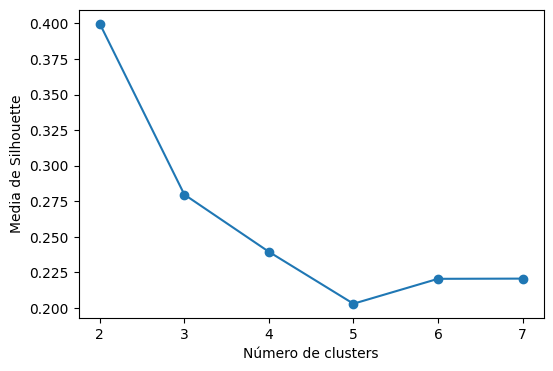

In [ ]:
rango = range(2,8) #probamos el número de clusters de 2 a 6
valores_medios = []
for k in rango:
  birch = Birch(n_clusters=k)
  etiquetas = birch.fit_predict(X_log)
  valores_m = silhouette_score(X_log, etiquetas) # El coeficiente necesita los datos y las etiquetas de los clusters
  valores_medios.append(valores_m)

# Gráfico de estos coeficienes donde lo que buscamos es el valor máximo
fig, ax = plt.subplots(1,1,figsize = (6,4))
ax.plot(rango, valores_medios, marker='o')
ax.set_xlabel('Número de clusters')
ax.set_ylabel('Media de Silhouette')

In [ ]:
birch = Birch(branching_factor=5, threshold=0.1) #Factor 5 es el estandar, se recomienda variar el umbral
birch.fit(X_log)
birch.get_params()

{'branching_factor': 5,
 'compute_labels': True,
 'copy': 'deprecated',
 'n_clusters': 3,
 'threshold': 0.1}

Con el coeficiente de silhouette se obitene un numero de clúster 2 como el optimo, sin embargo, el mejor que obtiene el algoritmo es de 3.

In [ ]:
labels = birch.predict(X_log)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Gráfico PCA'}>)

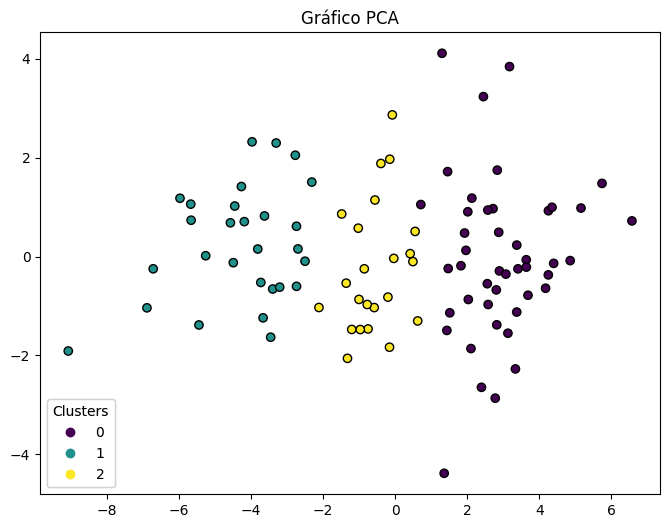

In [ ]:
plot_cluster(X_c, labels)

In [ ]:
df['BIRCH']=labels
df[features+['BIRCH']].groupby('BIRCH').mean()

,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2
BIRCH,,,,,,,,,,,
0,1.175778,16.466667,39.155556,240416.311111,135802.555556,313.333333,921.400000,27.755556,0.475556,3449.400000,7.986667
1,2.617857,74.178571,40.464286,8498.428571,3622.107143,10.642857,162.678571,32.321429,1.232143,161.107143,0.657143
2,2.404348,46.173913,29.739130,30517.913043,19109.565217,63.217391,725.652174,20.434783,2.613043,795.260870,2.582609


In [ ]:
df.query('Pais.str.contains("xico")',engine='python')[['Pais']+features+['BIRCH']]

,Pais,Tasa,Mortalidad,Mujeres,PNB,Luz,Telefonia,Agua,Bosques,Deforestacion,Energia,CO2,BIRCH
59,México,2.1,33,31,304596,147926,96,899,25,1.3,1561,3.8,0


---
***Características Clúster 0:***
---

*   **Económicas :**  En este grupo se encuentran los paises con el  `PNB`  más alto, una producción y consumo de energía bastante elevados y en promedio alrededor del 32% de  cada 1000 habitantes cuentan con una linea telefonica.
Con base en estos resultados podemos considerar a este grupo como paises desarrollados. En su mayoria son paises europeos y sorprendentemente México se encuentra en este grupo

*   **Sociales :** Para este grupo se observa un porcentaje moderado de `Mujeres`, un incremento poblacional bajo (`Tasa`),inclusive presenando tasas negativas, y una `Mortalidad` muy baja. Esto concuerda con los factores económicos pues tiene acceso a una mejor calidad de vida.

*   **Ambientales :** Presenta la más alta emisión de CO2 junto con un elevado consumo de Agua y una baja `Deforestacion` muy cercana a 0. Lo cual es entendible ya que al ser paises desarrollados tienen una mejor conciencia ambiental procurando conservar la mayor area natural posible.  


---
***Características Clúster 1:***
---

*   **Económicas :** Aquí encontramos a paises con numeros extremandamente mas bajos en comparación con el otro clúster, tratandose de paises con un bajo nivel de desarrollo o paises pequeños.

*   **Sociales :** Este grupo presenta los valores más altos en la `Mortalidad`, contrastando con una moderadamente elevada `Tasa` posiblemente debido a un gran flujo migratorio de otros paises hacia los de este grupo.

*   **Ambientales :** Con este grupo observamos la emisión de CO2 mas baja junto con el consumo de Agua mas bajo pero una `Deforestación` moderada y con la proporción cubierta de bosques mas grande. Posiblemente se trate de paises pequeños, con poca urbanización.

---

***Características Clúster 2:***
---

*   **Económicas :** Este grupo se encuentra enmedio de los dos anterioes con un `PNB` alto pero no lo suficiente como para entrar al clúster 0 y un bajo numero de `Telefonia` pero no lo suficiente para entar al clúster 1. Se podria considerar a los paises en este grupo como en vias de desarrollo.

*   **Sociales :** Este clúster esta mayormente conformado por paises de oriente medio, es por ello su baja cifra en `Mujeres`, cuentan con una `Mortalidad` moderada y aquí un cifra razonable en `Tasa` es posiblemente a la menor mortalida infantil que en el grupo 1.    
*   **Ambientales :** Con este clúster se tiene la mayor tasa de deforestación, lo que de alguna forma confirma que se trate de paises en vias de desarrollo. Ya que el consumo de `Agua` es elevado y tiene una considerable emisión de `CO2`.

---

In [ ]:
plot_econ(df, 'BIRCH')

alt.Chart(...)

In [ ]:
plot_social(df, 'BIRCH')

alt.Chart(...)

In [ ]:
plot_env(df, 'BIRCH')

alt.Chart(...)

# Análisis México

---
***KMeans***
---

El algoritmo agrupa a México con naciones ricas (Clúster 0): alto PNB, alto consumo de energía, amplia infraestructura, baja mortalidad infantil, poblaciones estables y una fuerza laboral femenina activa. Según los indicadores ambientales, se trata de países con altas emisiones, alto consumo de agua y baja deforestación.

El ajuste es deficiente. La economía de México está muy por debajo de los estándares del grupo, sus indicadores sociales son solo ligeramente mayores, sus emisiones son levemente bajas y su deforestación es notablemente alta. En lugar de confirmar su condición de país desarrollado, la clasificación revela a México como un caso atípico dentro de su propio grupo: una economía emergente clasificada erróneamente entre las avanzadas, o tal vez una economía que se ha desarrollado de manera desigual.

---
***Aglomerativos***
---

El grupo 0 agrupa a economías avanzadas con un PNB sólido, un alto consumo de energía y una alta densidad de telecomunicaciones, junto con estabilidad demográfica (baja mortalidad infantil, crecimiento poblacional moderado) y una participación significativa de la mujer en la fuerza laboral. Desde el punto de vista ambiental, estos países se caracterizan por altos niveles de CO₂, un elevado consumo de agua y bajos índices de deforestación.

La desviación de México es reveladora: se queda atrás respecto al grupo en las dimensiones económicas, se sitúa ligeramente por encima del promedio social, produce menos CO₂ per cápita, pero pierde más cobertura forestal. La asimetría —quedarse rezagado económicamente mientras se degrada más el medio ambiente— refuerza su condición de economía emergente.

---
***DBSCAN***
---

 El algoritmo asigna a México al Grupo 1, un grupo caracterizado por valores elevados en los indicadores económicos —producto nacional bruto, producción y consumo de energía, y líneas telefónicas—, junto con bajas tasas de mortalidad infantil y de crecimiento demográfico, y una participación femenina en la fuerza laboral moderadamente elevada. Estos países también presentan altas emisiones de CO₂ y un elevado consumo de agua, junto con bajos niveles de deforestación.

A pesar de esta clasificación, las cifras de México se sitúan significativamente por debajo de la media del grupo en los indicadores económicos, ligeramente por encima de la media en los indicadores sociales, con emisiones de CO₂ inferiores a la media y una deforestación superior a la media. Estos patrones sugieren que México sigue estando algo alejado de las economías plenamente desarrolladas y que es más adecuado clasificarlo como un mercado emergente.


---
***GMM***
---

Esta clasificación sitúa a México junto a países desarrollados que obtienen altos índices en PNB, producción y consumo de energía, y líneas telefónicas, con bajos índices de mortalidad infantil y crecimiento demográfico, además de una participación moderada de las mujeres en el mercado laboral. Estos países suelen presentar altos niveles de emisiones y consumo de agua, pero una deforestación moderada.

Sin embargo, el perfil de México se desvía: un desempeño económico más débil que los promedios del grupo, indicadores sociales ligeramente elevados, menores emisiones. Esto indica que México comparte algunas características de las economías desarrolladas, pero sigue siendo estructuralmente distinto; se entiende mejor como una economía emergente en transición hacia el estatus de país desarrollado, pero que aún no lo ha alcanzado.


---
***Propagación por Afinidad***
---

México se clasifica en el Grupo 1: países con perfiles económicos sólidos (alto PNB, consumo de energía e infraestructura de telecomunicaciones), resultados sociales favorables (baja mortalidad infantil y crecimiento demográfico lento) y una elevada participación económica de las mujeres. Los indicadores ambientales incluyen altos niveles de CO₂ y consumo de agua, pero una deforestación limitada.

Sin embargo, en comparación con los demás países de su grupo, México presenta un desempeño económico inferior, obtiene una puntuación social ligeramente superior al promedio, emite menos CO₂ y presenta una mayor tasa de deforestación. Esta divergencia respecto a los perfiles típicos de las naciones desarrolladas respalda su clasificación como economía emergente en lugar de desarrollada.


---
***BIRCH***
---

El algoritmo clasifica a México en el Grupo 0, una agrupación de naciones con economías prósperas —PIB sustancial, energía abundante, infraestructura de comunicaciones densa— donde la mortalidad infantil es baja, el crecimiento demográfico es moderado y las mujeres participan activamente en la fuerza laboral. En materia ambiental, estos países emiten grandes cantidades de gases de efecto invernadero, consumen agua vorazmente, pero mantienen sus bosques prácticamente intactos. México se encuentra aquí por conveniencia estadística, no por méritos propios.

Si se analiza más de cerca, la clasificación se desmorona. Su economía es un débil eco de la de sus pares del grupo. Sus indicadores sociales ofrecen solo un alivio marginal. Su huella de carbono es menor no por diseño, sino por el subdesarrollo industrial, y sus bosques desaparecen más rápido que los de naciones que supuestamente se encuentran en el mismo nivel ambiental. El algoritmo de agrupación ha sido generoso. Lo que surge es el retrato de un país invitado a un club que no puede permitirse, admitido por un tecnicismo y puesto al descubierto por cada desviación en los datos. «Economía emergente» es una etiqueta generosa; «luchando por emerger» tal vez sea más honesto.

In [ ]:
!pip --q install nbconvert

In [ ]:
!jupyter nbconvert --to html /content/MII_Final_Project.ipynb

[NbConvertApp] Converting notebook /content/MII_Final_Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 2961115 bytes to /content/MII_Final_Project.html
